# Анализ конверсии по воронке за 8 недель





In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

## 1. Загружаем данные

In [4]:
df = pd.read_excel('dannye-ce1e2d0f-249c-4782-a612-f0d6eeba56c0.xlsx')
df.head()

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
0,06.01.2025,Неделя 1,206,130,91,70,57,51
1,07.01.2025,Неделя 1,216,138,98,73,55,48
2,08.01.2025,Неделя 1,181,117,86,69,52,46
3,09.01.2025,Неделя 1,212,134,101,83,64,54
4,10.01.2025,Неделя 1,218,143,97,73,60,53


## 2. Очищаем данные



In [5]:
df = df[df['Дата'].astype(str).str.upper() != 'ИТОГО'].copy()
df

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
0,06.01.2025,Неделя 1,206,130,91,70,57,51
1,07.01.2025,Неделя 1,216,138,98,73,55,48
2,08.01.2025,Неделя 1,181,117,86,69,52,46
3,09.01.2025,Неделя 1,212,134,101,83,64,54
4,10.01.2025,Неделя 1,218,143,97,73,60,53
5,11.01.2025,Неделя 1,212,146,106,90,70,62
6,12.01.2025,Неделя 1,213,145,110,89,72,60
7,13.01.2025,Неделя 2,189,123,83,64,48,41
8,14.01.2025,Неделя 2,205,135,95,73,56,52
9,15.01.2025,Неделя 2,206,140,96,79,59,51


## 3. Группируем данные по неделям

In [6]:
stages = [
    'Установки',
    'Регистрации',
    'Открыли поиск',
    'Просмотрели авто',
    'Забронировали',
    'Первая поездка'
]

weekly = df.groupby('Неделя', as_index=False)[stages].sum()

# Достаём номер недели, чтобы правильно отсортировать строки
weekly['week_num'] = weekly['Неделя'].str.extract(r'(\d+)').astype(int)
weekly = weekly.sort_values('week_num').reset_index(drop=True)

weekly

,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка,week_num
0,Неделя 1,1458,953,689,547,430,374,1
1,Неделя 2,1415,933,661,522,411,368,2
2,Неделя 3,1433,973,721,581,440,379,3
3,Неделя 4,1407,956,688,549,415,364,4
4,Неделя 5,1433,956,696,556,440,383,5
5,Неделя 6,1357,922,653,516,411,373,6
6,Неделя 7,1526,1021,504,424,336,283,7
7,Неделя 8,1528,1031,519,421,335,299,8


## 4. Считаем конверсии между этапами

In [7]:
weekly['Установки → регистрации'] = weekly['Регистрации'] / weekly['Установки']
weekly['Регистрации → открыли поиск'] = weekly['Открыли поиск'] / weekly['Регистрации']
weekly['Поиск → просмотр авто'] = weekly['Просмотрели авто'] / weekly['Открыли поиск']
weekly['Просмотр авто → бронь'] = weekly['Забронировали'] / weekly['Просмотрели авто']
weekly['Бронь → первая поездка'] = weekly['Первая поездка'] / weekly['Забронировали']
weekly['Итоговая конверсия'] = weekly['Первая поездка'] / weekly['Установки']

weekly

,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка,week_num,Установки → регистрации,Регистрации → открыли поиск,Поиск → просмотр авто,Просмотр авто → бронь,Бронь → первая поездка,Итоговая конверсия
0,Неделя 1,1458,953,689,547,430,374,1,0.653635,0.722980,0.793904,0.786106,0.869767,0.256516
1,Неделя 2,1415,933,661,522,411,368,2,0.659364,0.708467,0.789713,0.787356,0.895377,0.260071
2,Неделя 3,1433,973,721,581,440,379,3,0.678995,0.741007,0.805825,0.757315,0.861364,0.264480
3,Неделя 4,1407,956,688,549,415,364,4,0.679460,0.719665,0.797965,0.755920,0.877108,0.258706
4,Неделя 5,1433,956,696,556,440,383,5,0.667132,0.728033,0.798851,0.791367,0.870455,0.267271
5,Неделя 6,1357,922,653,516,411,373,6,0.679440,0.708243,0.790199,0.796512,0.907543,0.274871
6,Неделя 7,1526,1021,504,424,336,283,7,0.669069,0.493634,0.841270,0.792453,0.842262,0.185452
7,Неделя 8,1528,1031,519,421,335,299,8,0.674738,0.503395,0.811175,0.795724,0.892537,0.195681


## 5. Строим график

На графике отдельно выделен этап **«Регистрации - открыли поиск»**, потому что именно там виден основной провал.

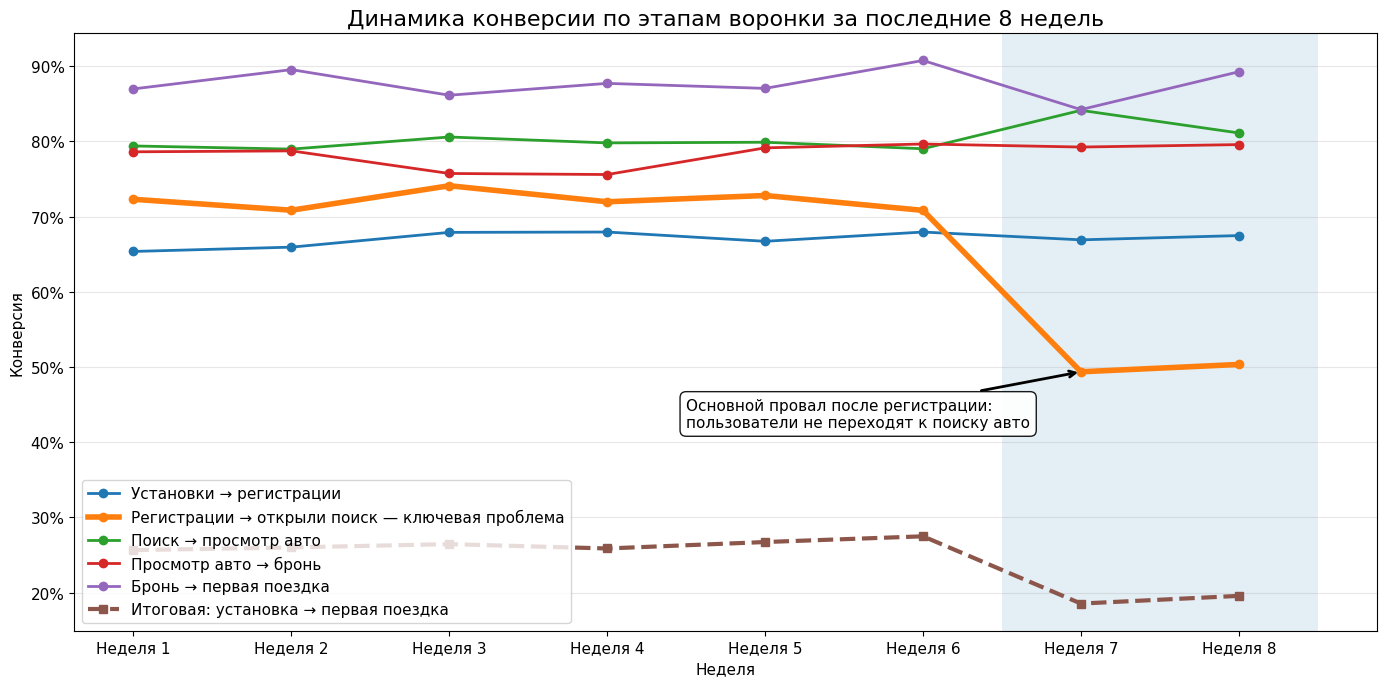

In [8]:
x = weekly['week_num']

plt.figure(figsize=(14, 7))

plt.plot(x, weekly['Установки → регистрации'], marker='o', linewidth=2, label='Установки → регистрации')
plt.plot(x, weekly['Регистрации → открыли поиск'], marker='o', linewidth=4, label='Регистрации → открыли поиск — ключевая проблема')
plt.plot(x, weekly['Поиск → просмотр авто'], marker='o', linewidth=2, label='Поиск → просмотр авто')
plt.plot(x, weekly['Просмотр авто → бронь'], marker='o', linewidth=2, label='Просмотр авто → бронь')
plt.plot(x, weekly['Бронь → первая поездка'], marker='o', linewidth=2, label='Бронь → первая поездка')
plt.plot(x, weekly['Итоговая конверсия'], marker='s', linestyle='--', linewidth=3, label='Итоговая: установка → первая поездка')

# Подсвечиваем последние 2 недели, где видно падение
plt.axvspan(6.5, 8.5, alpha=0.12)

plt.title('Динамика конверсии по этапам воронки за последние 8 недель', fontsize=16)
plt.xlabel('Неделя')
plt.ylabel('Конверсия')
plt.xticks(x, weekly['Неделя'])
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='lower left')

plt.annotate(
    'Основной провал после регистрации:\nпользователи не переходят к поиску авто',
    xy=(7, weekly.loc[weekly['week_num'] == 7, 'Регистрации → открыли поиск'].iloc[0]),
    xytext=(4.5, 0.42),
    arrowprops=dict(arrowstyle='->', linewidth=2),
    fontsize=11,
    bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.9)
)

plt.tight_layout()
plt.show()

## 6. Текстовое описание

По графику видно, что итоговая конверсия из установки в первую поездку снизилась на 7–8 неделях примерно с 26–28% до 19%. Основной провал происходит на этапе «Регистрации → Открыли поиск»: после регистрации заметно меньше пользователей переходят к поиску автомобиля. Конверсия на этом этапе снизилась примерно с 71–74% до 49–50%.

Главная проблема: пользователь проходит регистрацию, но дальше не совершает следующий ключевой шаг. Это может говорить о непонятном UX после регистрации, слабом онбординге, неочевидной кнопке перехода к поиску, технических ошибках или проблемах с доступами/геолокацией.

Гипотезы для увеличения конверсии:

1. Сделать более понятный первый экран после регистрации.
2. Добавить явный CTA «Найти авто».
3. Упростить онбординг и объяснить пользователю следующий шаг.
4. Проверить технические ошибки после регистрации.
5. Проанализировать записи сессий и клики пользователей.

Что проверить дальше: события после регистрации, ошибки приложения, устройства, версии приложения, источники трафика и поведение пользователей в первые минуты после регистрации.